In [ ]:
# import google drive and packages
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from google.colab import drive
drive.mount('/content/drive/')

Mounted at /content/drive/


In [ ]:

# load data with tensorflow
def preprocess_data(image_path, mask_path, input_shape, num_classes):
  image = tf.io.read_file(image_path)
  mask = tf.io.read_file(mask_path)
  # NEW - The images are saved in jpg
  image = tf.image.decode_jpeg(image, channels=1)
  mask = tf.image.decode_png(mask, channels=1)
  image = tf.image.convert_image_dtype(image, tf.float32)
  # NEW - The mask values should be normalized to 0, 1, 2, 3 by dividing by 50
  # mask = tf.math.divide(mask, 50) # If all classes are desired
  mask = tf.math.greater(mask, 0) # Background / overall tumor
  mask = tf.cast(mask, tf.int32)
  image = tf.image.resize(image, (input_shape[0], input_shape[1]))
  mask = tf.image.resize(mask, (input_shape[0], input_shape[1]), method=tf.image.ResizeMethod.NEAREST_NEIGHBOR)
  mask = tf.one_hot(mask, depth=num_classes)
  mask = tf.squeeze(mask, axis=-2)
  return image, mask

In [ ]:

# write tf generator
def create_data_pipeline(images_path, masks_path, input_shape, num_classes, seed, batch_size):
  # NEW - The images are saved in jpg
  images = tf.data.Dataset.list_files(images_path + '/*.jpg', seed=seed)
  masks = tf.data.Dataset.list_files(masks_path + '/*.png', seed=seed)
  dataset = tf.data.Dataset.zip((images, masks))
  # NEW - If only a (hardcoded) data subset is desired for faster iterations
  dataset = dataset.take(500)
  # NEW - Adding num_parallel_class optimizes the loading procedure
  dataset = dataset.map(lambda x, y: preprocess_data(x, y, input_shape, num_classes), num_parallel_calls=tf.data.experimental.AUTOTUNE)
  dataset = dataset.shuffle(buffer_size=len(dataset), seed=seed)
  dataset = dataset.batch(batch_size)
  # NEW - Adding prefetch optimizes the loading procedure
  dataset = dataset.prefetch(tf.data.experimental.AUTOTUNE)
  return dataset

In [ ]:
def dice_accuracy(y_true, y_pred, epsilon=1e-7):
  num_classes = y_true.shape[-1]
  y_true = tf.cast(y_true, tf.float32)
  y_pred_class = tf.one_hot(tf.argmax(y_pred, axis=-1), num_classes)
  y_true = y_true[..., 1:] # excluding background
  y_pred_class = y_pred_class[..., 1:] # excluding background
  intersection = tf.reduce_sum(y_true * y_pred_class, axis=[1, 2])
  union = tf.reduce_sum(y_true, axis=[1, 2]) + tf.reduce_sum(y_pred_class, axis=[1, 2])
  dice_scores = (2 * intersection + epsilon) / (union + epsilon)
  mean_dice = tf.reduce_mean(dice_scores)
  return mean_dice

In [ ]:

# Paths
train_images_path = '/content/drive/MyDrive/Veritas AI/Capstone project/BraTS 2018/train/images'
train_masks_path = '/content/drive/MyDrive/Veritas AI/Capstone project/BraTS 2018/train/masks'
val_images_path = '/content/drive/MyDrive/Veritas AI/Capstone project/BraTS 2018/val/images'
val_masks_path = '/content/drive/MyDrive/Veritas AI/Capstone project/BraTS 2018/val/masks'

#Settings
input_shape = (120, 120, 1)
num_classes = 2
batch_size = 16
epochs = 20

# Set the seed for reproducibility
seed = 42
np.random.seed(seed)
tf.random.set_seed(seed)



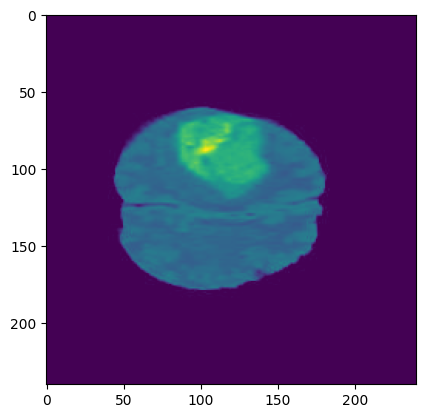

In [ ]:
from PIL import Image
import os
val_images_list = os.listdir(val_images_path)
val_images_list.sort()
val_masks_list = os.listdir(val_masks_path)
val_masks_list.sort()
val_image = Image.open(os.path.join(val_images_path, val_images_list[0]))
val_image = np.array(val_image)
plt.imshow(val_image)

In [1]:
k = 20

val_image = Image.open(os.path.join(val_images_path, val_images_list[k]))
val_image = np.array(val_image)
val_mask = Image.open(os.path.join(val_masks_path, val_masks_list[k]))
val_mask = np.array(val_mask)

plt.figure()
plt.subplot(1, 2, 1)
plt.imshow(val_image, cmap='bone')
plt.xlabel('image')
plt.subplot(1, 2, 2)
plt.imshow(val_mask, cmap='bone')
plt.xlabel('mask')
plt.show()

plt.figure()
plt.subplot(1, 2, 1)
plt.hist(val_image.ravel())
plt.xlabel('image histogram')
plt.subplot(1, 2, 2)
plt.hist(val_mask.ravel())
plt.xlabel('mask histogram')
plt.show()

print('--- Some stats for the selected image ---')
print('The minium value is: ' + str(np.min(val_image)))
print('The maximum value is: ' + str(np.max(val_image)))
print('The mean value is: ' + str(int(np.mean(val_image))))
print('The std value is: ' + str(int(np.std(val_image))))

print('--- Some stats for the selected mask ---')
print('The minium value is: ' + str(np.min(val_mask)))
print('The maximum value is: ' + str(np.max(val_mask)))
print('The mean value is: ' + str(int(np.mean(val_mask))))
print('The std value is: ' + str(int(np.std(val_mask))))
# NEW - Find the unique pixels
print('The unique pixel values are: ')
print(np.unique(val_mask))

NameError: name 'Image' is not defined

In [ ]:
val_image.shape

(240, 240)

In [ ]:
# test the dataset generator function
train_dataset = create_data_pipeline(train_images_path, train_masks_path, input_shape, num_classes, seed, batch_size)
val_dataset = create_data_pipeline(val_images_path, val_masks_path, input_shape, num_classes, seed, batch_size)

In [ ]:
# visualize images and mask


In [ ]:
from keras.utils.sidecar_evaluator import optimizer
# define the model
# U-Net of 2 levels

# Define input layer with the input shape
input_layer = tf.keras.layers.Input(shape=input_shape)

# Encoder path

# First level
x = tf.keras.layers.Conv2D(32, 3, activation='relu', padding='same')(input_layer)
x = tf.keras.layers.Conv2D(32, 3, activation='relu', padding='same')(x)
skips_1 = x # Save it for later!
x = tf.keras.layers.MaxPooling2D(2, strides=2)(x)

# Second level
x = tf.keras.layers.Conv2D(64, 3, activation='relu', padding='same')(x)
x = tf.keras.layers.Conv2D(64, 3, activation='relu', padding='same')(x)
skips_4 = x # Save it for later!
x = tf.keras.layers.MaxPooling2D(2, strides=2)(x)
# Decoder path

# Bottle neck
x = tf.keras.layers.Conv2D(128, 3, activation='relu', padding='same')(x)
x = tf.keras.layers.Conv2D(128, 3, activation='relu', padding='same')(x)
x = tf.keras.layers.Conv2DTranspose(64, kernel_size=(2, 2), strides=(2, 2), padding='same')(x)

# Second level
x = tf.keras.layers.concatenate([x, skips_4]) # concatenating!
x = tf.keras.layers.Conv2D(64, 3, activation='relu', padding='same')(x)
x = tf.keras.layers.Conv2D(64, 3, activation='relu', padding='same')(x)
x = tf.keras.layers.Conv2DTranspose(32, kernel_size=(2, 2), strides=(2, 2), padding='same')(x)

# First level
x = tf.keras.layers.concatenate([x, skips_1]) # concatenating!
x = tf.keras.layers.Conv2D(16, 3, activation='relu', padding='same')(x)
x = tf.keras.layers.Conv2D(16, 3, activation='relu', padding='same')(x)

# Define the output layer
output_layer = tf.keras.layers.Conv2D(num_classes, 1, activation='softmax')(x)

# Create model
baseline_unet_model = tf.keras.models.Model(inputs=input_layer, outputs=output_layer)

baseline_unet_model.compile(loss=tf.keras.losses.CategoricalCrossentropy(), optimizer=tf.keras.optimizers.Adam(), metrics = [dice_accuracy])

In [ ]:
# train the model
history = baseline_unet_model.fit(train_dataset, validation_data=val_dataset, epochs = epochs)

Epoch 1/20


In [ ]:
def plot_graphs(history, metric):
  plt.figure(figsize=(16, 6))
  plt.plot(history.history[metric])
  plt.plot(history.history['val_'+metric], '')
  plt.xlabel("Epochs")
  plt.ylabel(metric)
  plt.legend(["Train", "Validation"])

In [ ]:
# test the model
def convert_tf_data_to_np(dataset):
  images = []
  masks = []
  for image, mask in dataset:
    images.append(image.numpy())
    masks.append(mask.numpy())
  images = np.concatenate(images, axis=0)
  masks = np.concatenate(masks, axis=0)
  return images, masks

def get_DSC(A, B, epsilon=1e-7):
  intersection = np.sum(A * B)
  Asum = np.sum(A)
  Bsum = np.sum(B)
  DSC = (2 * intersection + epsilon) / (Asum + Bsum + epsilon)
  return DSC

def evaluate_DSC_in_data(masks_gt, masks_pred, num_classes):
  num_samples = masks_gt.shape[0]
  DSCs = np.zeros((num_samples, num_classes))
  for i in range(num_samples):
    for j in range(num_classes):
      DSCs[i, j] = get_DSC(masks_gt[i, :, :]==j, masks_pred[i, :, :]==j)
  DSCs = DSCs[:, 1:] # excluding background
  mean_DSC = np.mean(DSCs)
  return DSCs, mean_DSC

In [ ]:
X_val, Y_val = convert_tf_data_to_np(val_dataset)
Y_val = np.argmax(Y_val, axis=-1)

In [ ]:
Y1_pred = baseline_unet_model.predict(X_val)
Y1_pred = np.argmax(Y1_pred, axis=-1)

In [ ]:
baseline_DSCs, baseline_mean_DSC = evaluate_DSC_in_data(Y_val, Y1_pred, num_classes)
print(baseline_mean_DSC)

In [ ]:
# iterate and try more models

In [ ]:
def get_list_of_patients_with_their_slices(images_list):
  patients_list = []
  patient_list = []
  patient_ID = []
  patient_slices = []
  patient_name = 'placeholder'
  for image_file in images_list:
    image_file_components = image_file.split('_')
    new_patient_name = image_file_components[0] + '_' + image_file_components[1]
    if new_patient_name != patient_name:
      patient_list = [patient_ID, patient_slices]
      patients_list.append(patient_list)
      patient_ID = new_patient_name
      patient_slices = []
      patient_name = new_patient_name
    patient_slices.append(image_file)
  patients_list = patients_list[1:]
  return patients_list

In [ ]:
from skimage.transform import resize
def calculate_volumes(patients_list, trained_model):
  volumes_gt = np.zeros((len(patients_list), 1))
  volumes_pred = np.zeros((len(patients_list), 1))
  k = 0
  for patient_list in patients_list:
    volume_gt = 0
    volume_pred = 0
    for MRI_slice in patient_list[1]:
      image_path = os.path.join(val_images_path, MRI_slice)
      mask_path = os.path.join(val_masks_path, MRI_slice[0:-4] + '.png')
      image = np.array(Image.open(image_path).resize((input_shape[1], input_shape[0]))) / 255
      image = np.expand_dims(image, axis=(0, 3))
      mask_gt = np.array(Image.open(mask_path)) / 50
      mask_gt = (mask_gt > 0).astype(float)
      mask_pred = trained_model.predict(image, verbose=0)
      mask_pred = np.argmax(mask_pred, axis=-1)
      mask_pred = mask_pred[0, :, :]
      mask_pred = (mask_pred > 0).astype(float)
      mask_pred = resize(mask_pred, mask_gt.shape, order=0)
      area_gt = np.sum(mask_gt==1) * 1 * 1
      area_pred = np.sum(mask_pred==1) * 1 * 1
      volume_gt = volume_gt + (area_gt * 3.5) / 1000
      volume_pred = volume_pred + (area_pred * 3.5) / 1000
    volumes_gt[k, 0] = volume_gt
    volumes_pred[k, 0] = volume_pred
    k = k + 1
  return volumes_gt, volumes_pred

In [ ]:
patients_list = get_list_of_patients_with_their_slices(val_images_list)

baseline_volumes_gt, baseline_volumes_pred = calculate_volumes(patients_list, baseline_unet_model)

In [ ]:
import statsmodels.api as sm
from scipy.stats import linregress, pearsonr

In [ ]:
sm.graphics.mean_diff_plot(baseline_volumes_pred, baseline_volumes_gt)

In [ ]:
slope, intercept, r_value, p_value, std_err = linregress(baseline_volumes_gt, baseline_volumes_pred)
line = slope * baseline_volumes_gt + intercept
r, p = pearsonr(baseline_volumes_gt, baseline_volumes_pred)

plt.figure()
plt.scatter(baseline_volumes_gt, baseline_volumes_pred)
plt.plot(baseline_volumes_gt, line, 'r', label='y={:.2f}x+{:.2f}, r={:.2f}'.format(slope, intercept, r))
plt.xlabel('X')
plt.ylabel('Y')
plt.legend(loc='best')
plt.show()